# EBM model with decreasing albedo

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from ebm.params import *

%load_ext autoreload

## Global mean temp data

In [2]:
%autoreload
from esm.model import get_global_mean

global_mean_r25, global_mean_r1, global_mean_pi = get_global_mean()

/home/green/code/climate-modelling/climate-modelling-ebm/esm/model.py:7: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds_pi =xr.open_dataset('../data/tas_Amon_MPI-ESM1-2-LR_piControl_r1i1p1f1_g025_185001-284912.nc')
/home/green/code/climate-modelling/climate-modelling-ebm/esm/model.py:7: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds_pi =xr.open_dataset('../data/tas_Amon_MPI-ESM1-2-LR_piControl_r1i1p1f1_g025_185001-284912.nc')
/home/green/code/climate-modelling/climate-modelling-ebm/esm/model.py:7: SerializationWarning: Unable to decode time axis into full numpy.

## EBM Params

In [3]:
start_year = 1980
T_init = global_mean_r25.sel(time=str(start_year)).values[0]

params = {
    'T_init': T_init,
}

print(params['T_init'])

287.19958356396137


## Albedo decrease from literature

In [4]:
# Albedo decreases by 0.34% = 0.0034 per decade
slope_decade = -0.0034 
slope_yr = slope_decade/10

## Run model with constant and decreasing albedo

In [5]:
%autoreload
from ebm.model import model_alpha, run_model

# Original model setup
temp_original, time_original = run_model(T_ini=T_init, maxtime=120*secyear)

# Define parameters
params['alpha_init'] = 0.31
params['maxtime'] = 120*secyear
params['dt'] = secday

# Decreasing albedo from lit: -0.34% per decade
params['alpha_slope'] = slope_yr/secyear    # slope in 1/s
print(f'albedo (alpha) decreases by {params['alpha_slope']*secyear*100:.3f}% per year')
T1, time1, alpha1 = model_alpha(params)

# Slower decreasing albedo: -0.17% per decade
params['alpha_slope'] = (slope_yr/2)/secyear    # slope in 1/s
print(f'albedo (alpha) decreases by {params['alpha_slope']*secyear*100:.3f}% per year')
T2, time2, alpha2 = model_alpha(params)

albedo (alpha) decreases by -0.034% per year
albedo (alpha) decreases by -0.017% per year


## Linear trend of increased global warming

In [6]:
t_linreg = global_mean_r25.sel(time=slice('1980', '2100')).time.dt.year
T_linreg = global_mean_r25.sel(time=slice('1980', '2100')) - 273.15

fit = np.polyfit(t_linreg, T_linreg, 1)
print(f'T(t) = {fit[0]:.2f} * t + {fit[1]:.2f},     1980 < t < 2100')

xp = np.linspace(1980, 2100)
p = np.poly1d(fit)

T(t) = 0.02 * t + -22.46,     1980 < t < 2100


## Plot albedo timeseries

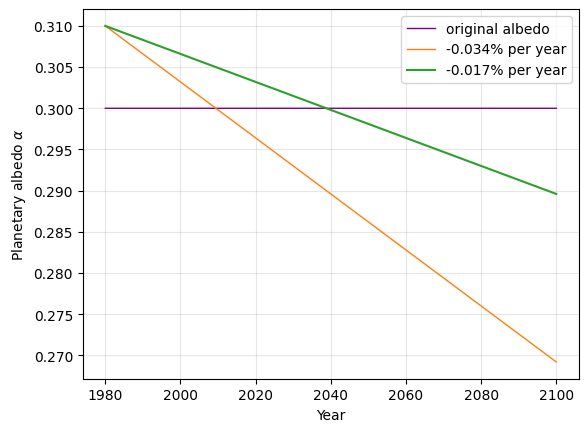

In [7]:
# Plot albedo over time
plt.plot(time1+start_year, np.ones(len(time1))*ORIGINAL_alpha, label=f'original albedo', c='purple', lw=1)
plt.plot(time1+start_year, alpha1, label=f'{slope_decade*10:.3f}% per year', c='tab:orange', lw=1)
plt.plot(time2+start_year, alpha2, label=f'{params['alpha_slope']*secyear*100:.3f}% per year', c='tab:green')

plt.xlabel('Year')
plt.ylabel(r'Planetary albedo $\alpha$')
plt.grid(alpha=0.3)
plt.legend()
plt.savefig('plots/albedo-timeseries.png', bbox_inches='tight')
plt.savefig('plots/albedo-timeseries.pdf', bbox_inches='tight')

## Plot global mean temp

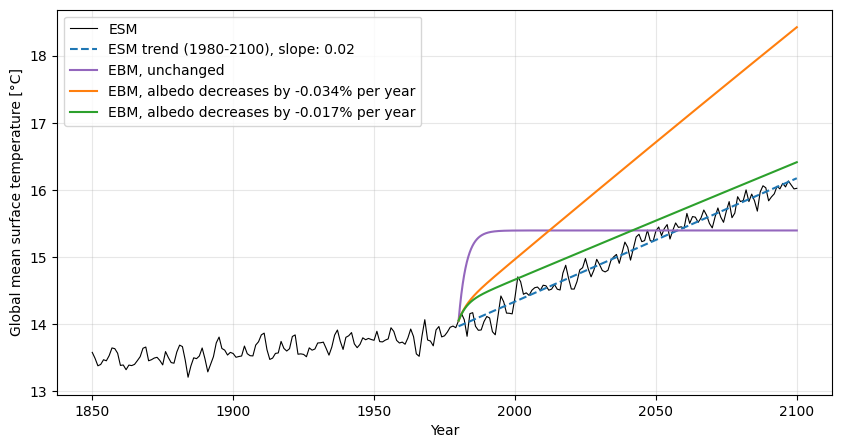

In [8]:
# Make figure
fig = plt.figure(figsize=(10,5))
    
# Plot ESM output
plt.plot(global_mean_r25.time.dt.year, global_mean_r25-273.15, lw=0.8, label='ESM', c='k')

# Plot ESM trend (1980-2100)
plt.plot(xp, p(xp), label=f'ESM trend (1980-2100), slope: {fit[0]:.2f}', ls='dashed')

# Plot EBM output, unchanged params
plt.plot(time_original+start_year, temp_original, label='EBM, unchanged', c='tab:purple')

# Plot EBM output, decreasing albedo
plt.plot(time1+start_year, T1, label=f'EBM, albedo decreases by {slope_decade*10:.3f}% per year', c='tab:orange')
plt.plot(time2+start_year, T2, label=f'EBM, albedo decreases by {params['alpha_slope']*secyear*100:.3f}% per year', c='tab:green')

# Fig settings
plt.grid(alpha=0.3)
plt.legend()
plt.xlabel('Year')
plt.ylabel('Global mean surface temperature [°C]')
plt.legend()

# Save and show
plt.savefig('plots/unchanged-vs-linear-albedo-vs-trend.png', bbox_inches='tight')
plt.savefig('plots/unchanged-vs-linear-albedo-vs-trend.pdf', bbox_inches='tight')
plt.show()


- observed albedo decrease 0.034% per year -> temp too high -> there must be some counteracting process that cools the earth that is not accounted for in this EBM -> accelerated warming not fully explained by the observed albedo decrease alone (rethink phrasing)
- trend matches ESM trend if albedo decreases only half as quickly as irl